# Inspect ten held-out reconstructions and charges

Load the saved 10-epoch model and compare **ten deterministic molecules from the held-out test split** with their latent-only reconstructions. No training, Psi4, CCDC access, or W&B upload runs here.

**Reading the figures:** blue atoms/bonds are the original heavy-atom structure; orange crosses are decoded atoms. The decoder predicts positions, elements, and charges, but **not bonds or atom count**. We draw only original bonds. Atom correspondence uses position-only Hungarian matching in the centered encoder frame, without a fitted rotation. Wrong predicted elements are marked in red.

**Charge caveat:** these are Psi4/RESP labels that passed the repository's provenance, convergence, charge-sum, and ±2 e trust gates. That gate is a model-compatibility filter, not proof of chemical accuracy. The model output is bounded to ±2 e. All charges below absorb each hydrogen's charge into its bonded heavy atom.

Use the `.pixi/envs/ml-gpu/bin/python` kernel (or the CPU ML kernel). Set `DEVICE = "cpu"` to force CPU. Run from the repository or its `notebooks/` directory.

In [1]:
from pathlib import Path
import sys, json, copy, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/ccdc-notebook-matplotlib")
ROOT = Path.cwd().resolve()
if not (ROOT / "MolFLAE").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "MolFLAE").is_dir(), "Run from the repository or notebooks directory"
sys.path.insert(0, str(ROOT / "scripts"))
RUN = ROOT / "runs/trusted-split80-20-10epoch"
CHECKPOINT = RUN / "last.ckpt"
TEST = ROOT / "runs/csd-small-v1-trusted-v3-split80-20/test"
DEVICE = "auto"  # auto, cpu, cuda, cuda:N
SAMPLE_STEPS = 100
SEED = 2043
N_MOLECULES = 10
# Change these IDs explicitly to inspect other test molecules.
run_info = json.loads((RUN / "run.json").read_text())
MOLECULE_IDS = run_info["test_ids"][:N_MOLECULES]
print("Fixed test IDs:", MOLECULE_IDS)


Fixed test IDs: ['ABUMIT', 'ACEMID11', 'ADUQOF', 'AMBNAC17', 'AMIPYR01', 'AMOREA', 'ASAJOX', 'BEDMON', 'BIDJIH', 'BIYMOP']


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.optimize import linear_sum_assignment
from rdkit import Chem
from torch_geometric.loader import DataLoader
from _workflow.data import structures, load_labels, digest
from _workflow.training import molecular_data, load_pretrained, resolve_device, charge_predictions
from _workflow.metrics import inputs

assert CHECKPOINT.is_file(), f"Missing checkpoint: {CHECKPOINT}"
assert len(MOLECULE_IDS) == len(set(MOLECULE_IDS))
assert set(MOLECULE_IDS) <= set(run_info["test_ids"])
assert not set(MOLECULE_IDS) & set(run_info["train_ids"])
all_records = {r[0]: r for r in structures(TEST / "sdf")}
records = [all_records[i] for i in MOLECULE_IDS]
labels, verified = load_labels(TEST / "charges/charges.npz", records)
assert verified, "Require source-verified labels"
for identifier, source, _ in records:
    assert digest(source) == run_info["test_source_sha256"][identifier]
config = copy.deepcopy(json.loads((RUN / "config.json").read_text()))
device = resolve_device(DEVICE, config)
torch.set_num_threads(2)
model, loaded = load_pretrained(config, CHECKPOINT, device)
assert not loaded["new_charge_head"], "Expected a trained charge head"
model.eval()
model.external_logging = True
data = molecular_data(records, labels)
print(f"Loaded {CHECKPOINT.name} on {device}; {len(data)} held-out molecules")


/home/vlad/code/ccdc/.pixi/envs/ml-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Encoder params: 2.96M
KL layer params: 0.01M
Decoder params: 2.84M
Of which 16641 are charge head params.
total params: 5.81M



Loaded last.ckpt on cuda:0; 10 held-out molecules


## Decode and establish atom correspondence

The encoder receives the original heavy atoms. The sampling decoder receives only the resulting latent representations and atom counts; it does not receive original coordinates/types. We also compute a separate **supplied-geometry charge prediction** for comparison. Sampling is seeded, but these ten-molecule batches differ from the full evaluation batches, so per-molecule samples may differ from the training report.

In [3]:
results = []
loader = DataLoader(data, batch_size=len(data), shuffle=False)
cuda_devices = [device.index if device.index is not None else torch.cuda.current_device()] if device.type == "cuda" else []
with torch.random.fork_rng(devices=cuda_devices), torch.no_grad():
    torch.manual_seed(SEED)
    batch = next(iter(loader)).to(device)
    x, indices, types = inputs(model, batch)
    zh, zx, global_batch, _, _ = model.encode(types, x, batch.batch, deterministic=True)
    _, trajectory, _ = model.decoder.sample(
        protein_pos=zx, protein_v=zh, batch_protein=global_batch,
        batch_ligand=batch.batch, n_nodes=len(x), sample_steps=SAMPLE_STEPS,
        desc="Ten test reconstructions")
    positions, probabilities, predicted_q, _ = trajectory[-1]
    geometry_q = charge_predictions(model, batch)
    for i, (identifier, _, mol) in enumerate(records):
        mask = batch.batch == i
        ref = x[mask].cpu().numpy()
        pred = positions[mask].cpu().numpy()
        pred = pred - pred.mean(axis=0)
        a, b = linear_sum_assignment(((ref[:, None] - pred[None]) ** 2).sum(-1))
        assert np.array_equal(a, np.arange(len(ref)))
        target_q = batch.charges[mask].flatten().cpu().numpy()
        decoded_q = predicted_q[mask].flatten().cpu().numpy()[b]
        known_q = geometry_q[mask].flatten().cpu().numpy()
        atomic_numbers = np.array([6, 7, 8, 9, 15, 16, 17, 35, 53])
        actual_z = batch.h[mask].flatten().cpu().numpy()
        decoded_z = atomic_numbers[probabilities[mask].argmax(-1).cpu().numpy()[b]]
        heavy = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() != 1]
        mapping = {original: local for local, original in enumerate(heavy)}
        bonds = [(mapping[bond.GetBeginAtomIdx()], mapping[bond.GetEndAtomIdx()])
                 for bond in mol.GetBonds()
                 if bond.GetBeginAtomIdx() in mapping and bond.GetEndAtomIdx() in mapping]
        item = dict(identifier=identifier, reference=ref, decoded=pred[b],
                    reference_z=actual_z, decoded_z=decoded_z,
                    reference_q=target_q, decoded_q=decoded_q, geometry_q=known_q,
                    bonds=bonds, source_atom_indices=heavy, decoded_indices=b)
        for key in ("reference", "decoded", "reference_q", "decoded_q", "geometry_q"):
            assert np.isfinite(item[key]).all(), key
        item["position_rmse_A"] = float(np.sqrt(np.mean(np.sum((ref - pred[b]) ** 2, axis=1))))
        item["atom_accuracy"] = float(np.mean(actual_z == decoded_z))
        item["decoded_charge_mae_e"] = float(np.mean(np.abs(decoded_q - target_q)))
        results.append(item)
    del trajectory

print("ID           position RMSE (Å)   atom accuracy   decoded charge MAE (e)")
for r in results:
    print(f"{r['identifier']:12s} {r['position_rmse_A']:10.3f} {r['atom_accuracy']:17.1%} {r['decoded_charge_mae_e']:21.3f}")


Ten test reconstructions:   0%|          | 0/100 [00:00<?, ?it/s]

Ten test reconstructions:   7%|▋         | 7/100 [00:00<00:01, 67.19it/s]

Ten test reconstructions:  18%|█▊        | 18/100 [00:00<00:00, 88.64it/s]

Ten test reconstructions:  29%|██▉       | 29/100 [00:00<00:00, 95.23it/s]

Ten test reconstructions:  40%|████      | 40/100 [00:00<00:00, 98.37it/s]

...

Ten test reconstructions:  73%|███████▎  | 73/100 [00:00<00:00, 103.00it/s]

Ten test reconstructions:  84%|████████▍ | 84/100 [00:00<00:00, 103.00it/s]

Ten test reconstructions:  95%|█████████▌| 95/100 [00:00<00:00, 102.74it/s]

Ten test reconstructions: 100%|██████████| 100/100 [00:01<00:00, 99.87it/s]

ID           position RMSE (Å)   atom accuracy   decoded charge MAE (e)
ABUMIT            0.049            100.0%                 0.015
ACEMID11          0.038            100.0%                 0.038
ADUQOF            0.209            100.0%                 0.023
AMBNAC17          0.103            100.0%                 0.041
AMIPYR01          0.047            100.0%                 0.032
AMOREA            0.060            100.0%                 0.261
ASAJOX            0.216            100.0%                 0.038
BEDMON            0.346            100.0%                 0.017
BIDJIH            0.108            100.0%                 0.073
BIYMOP            0.697            100.0%                 0.029


## Structure overlays and charge comparisons

Atom labels use the **zero-based heavy-atom index**. Charge maps share the full reference/decoded color range. The atom-wise comparison has a larger **zoomed view** and a smaller **full-range view** underneath. The zoom scales around predicted charges; out-of-range reference values are marked with boundary triangles and remain visible in the full-range panel. The ±2 e model bound no longer forces the axes to expand.

The loop writes one figure per held-out molecule plus `predictions.json` to a fresh ignored `runs/reconstruction-inspection-*` directory. Set `CHARGE_YLIM = (-0.3, 0.3)` for an explicit zoom range, or leave it as `None` for automatic scaling per molecule. Change `ELEVATION` and `AZIMUTH` to adjust the static 3D views.

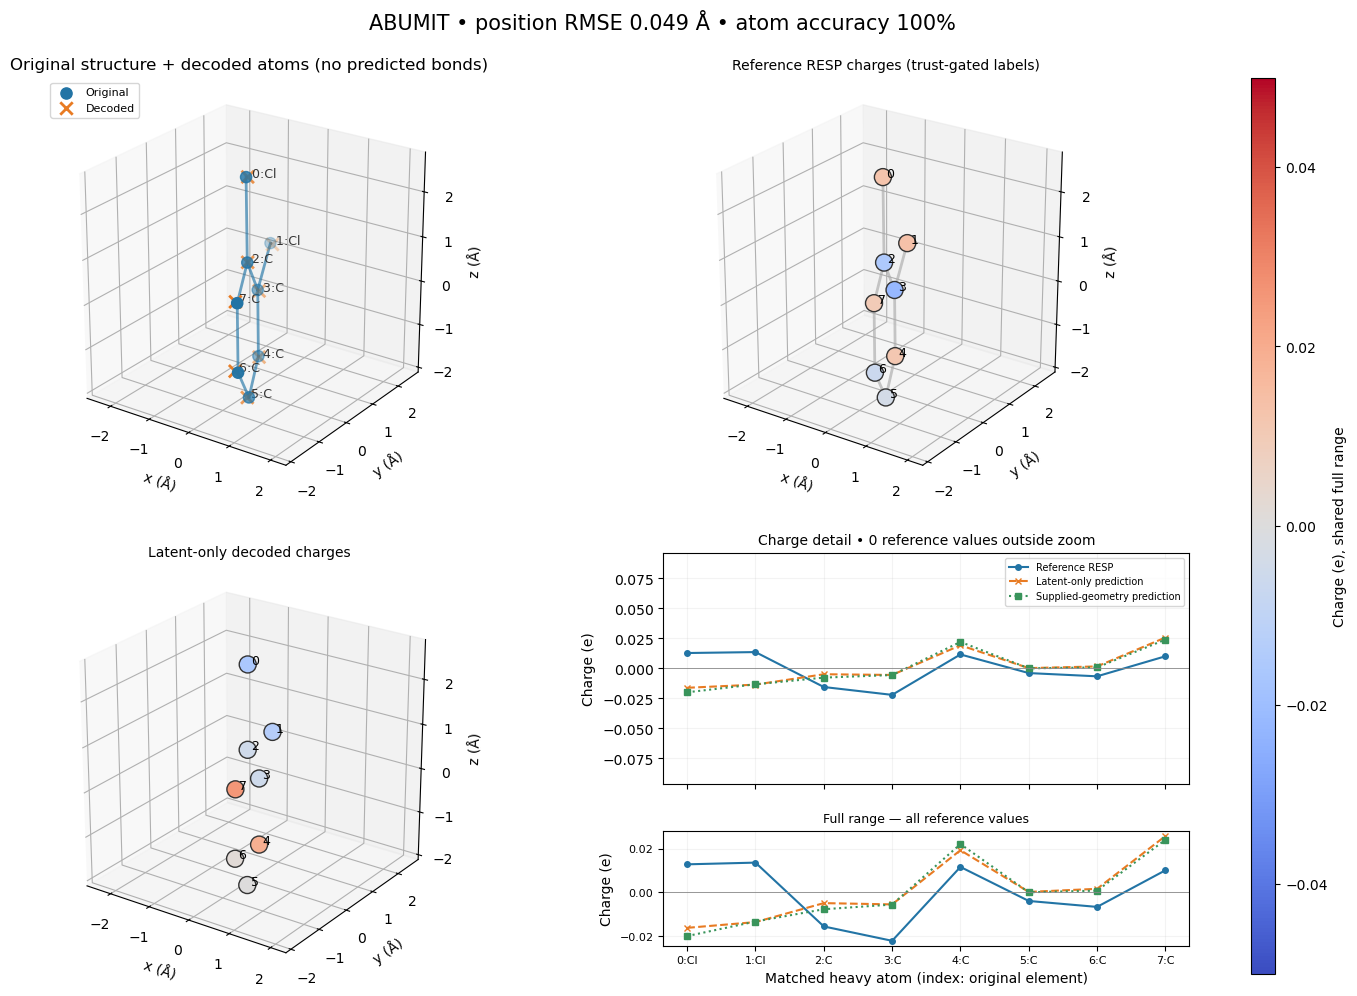

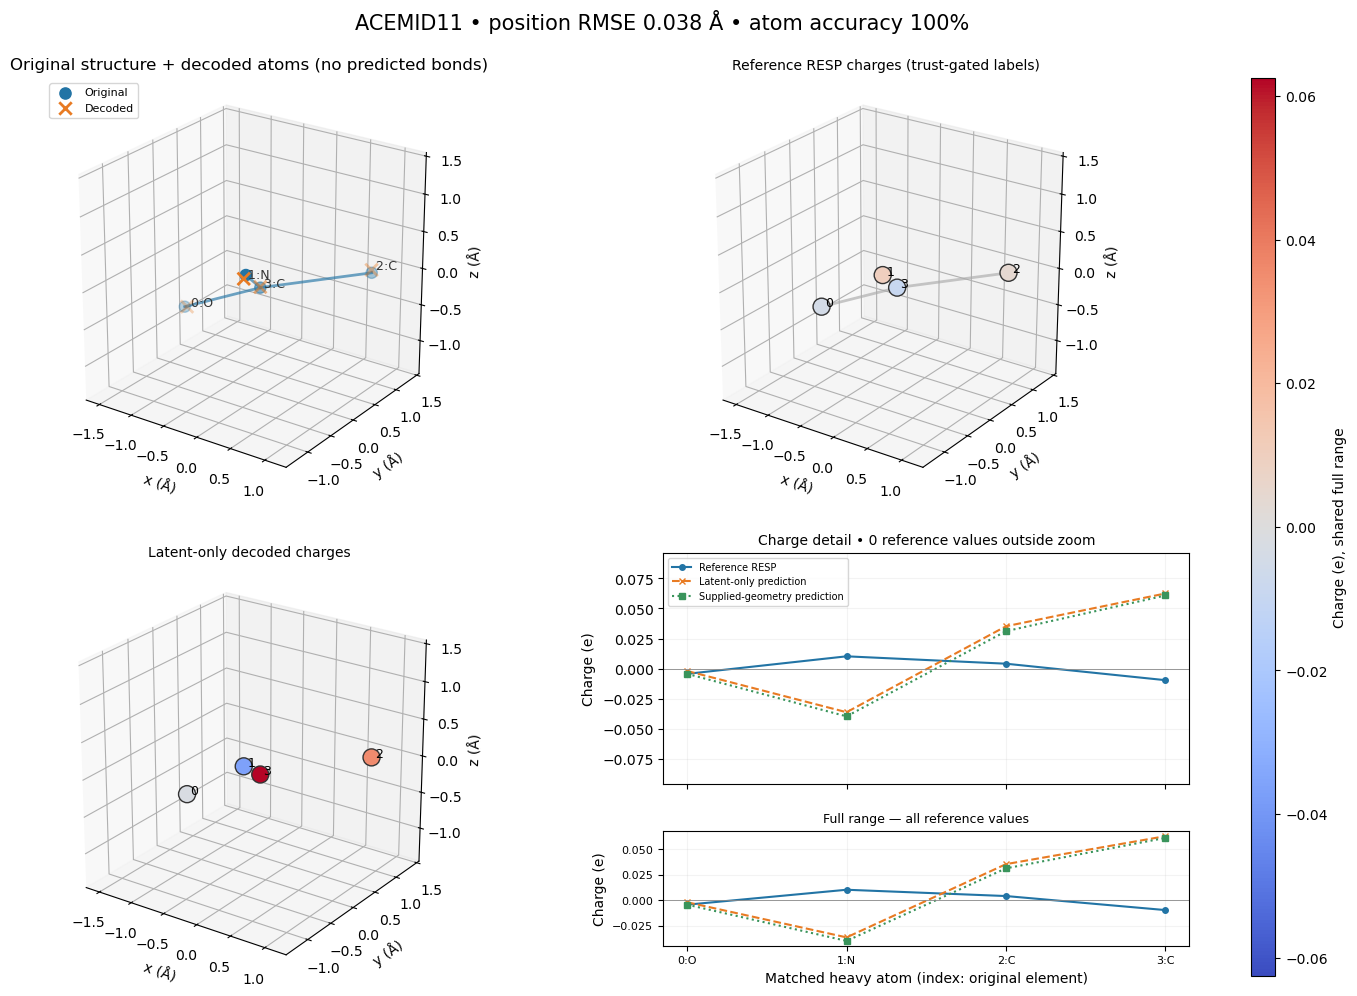

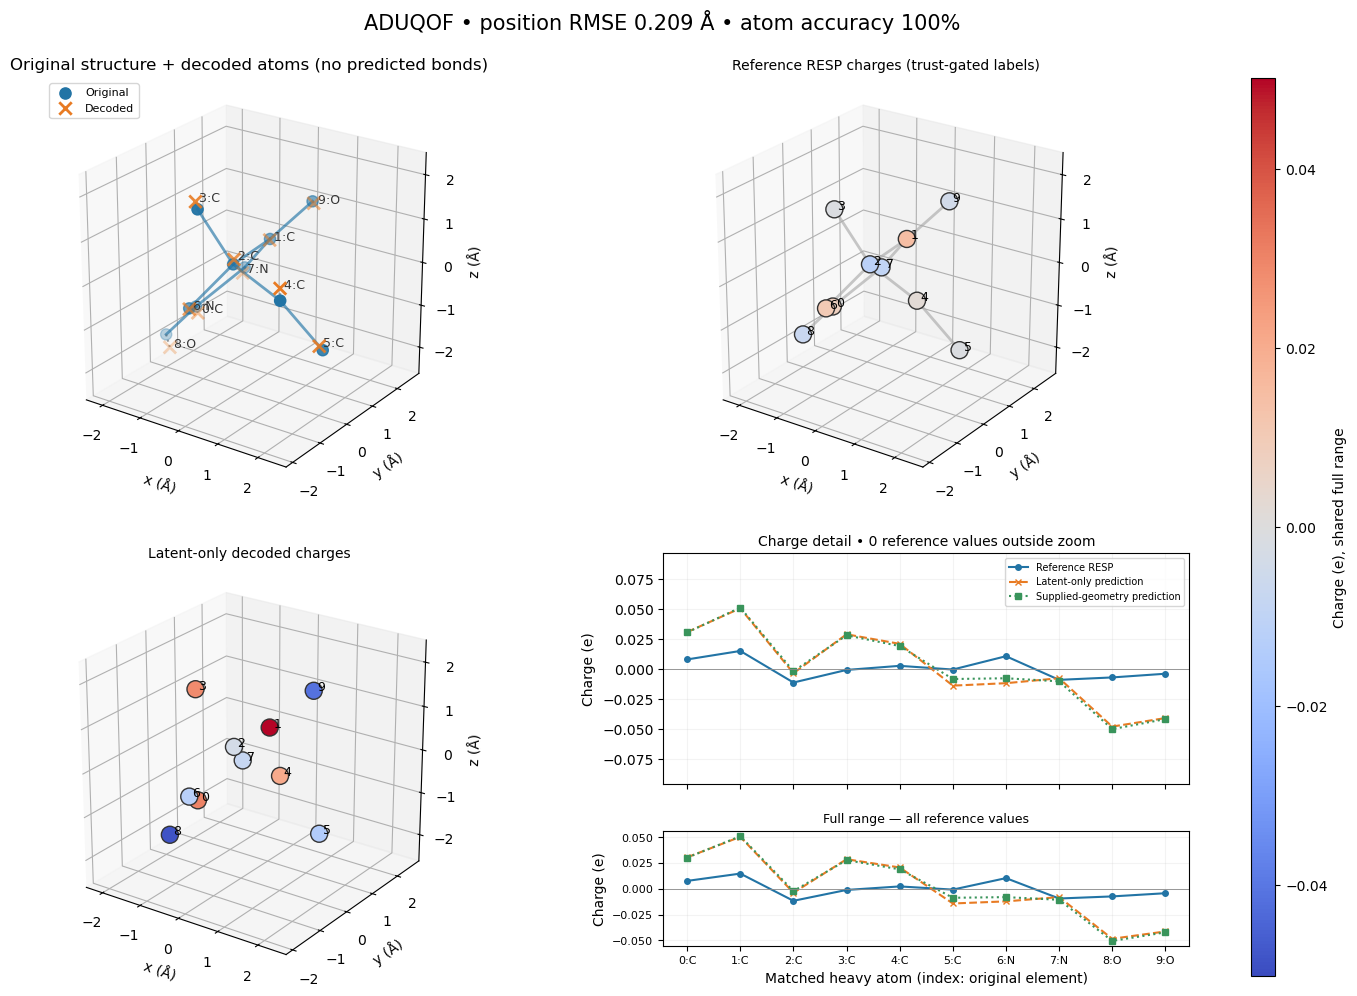

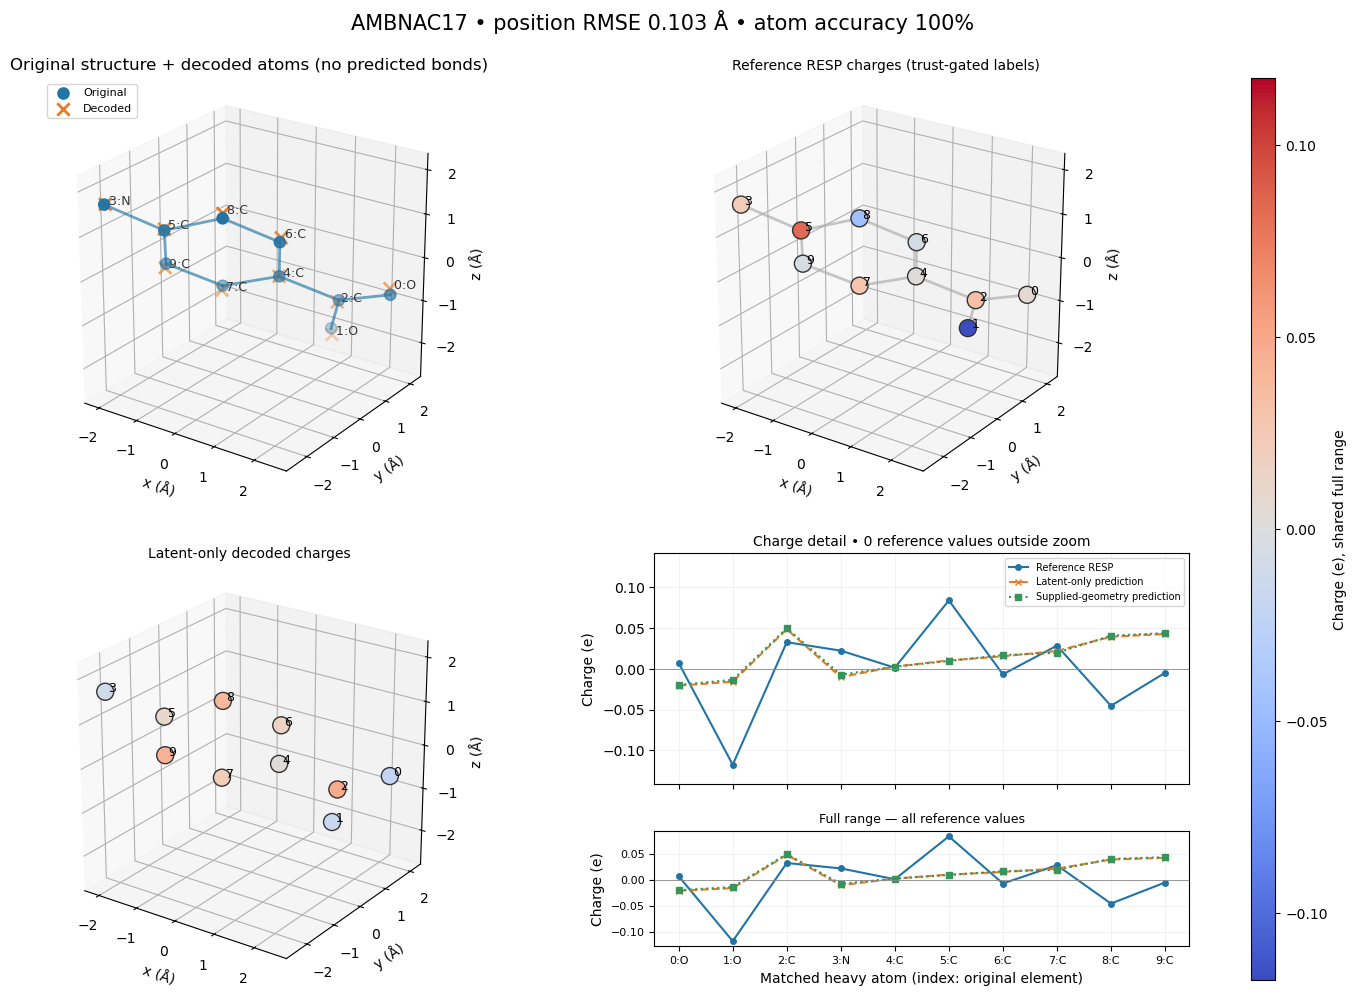

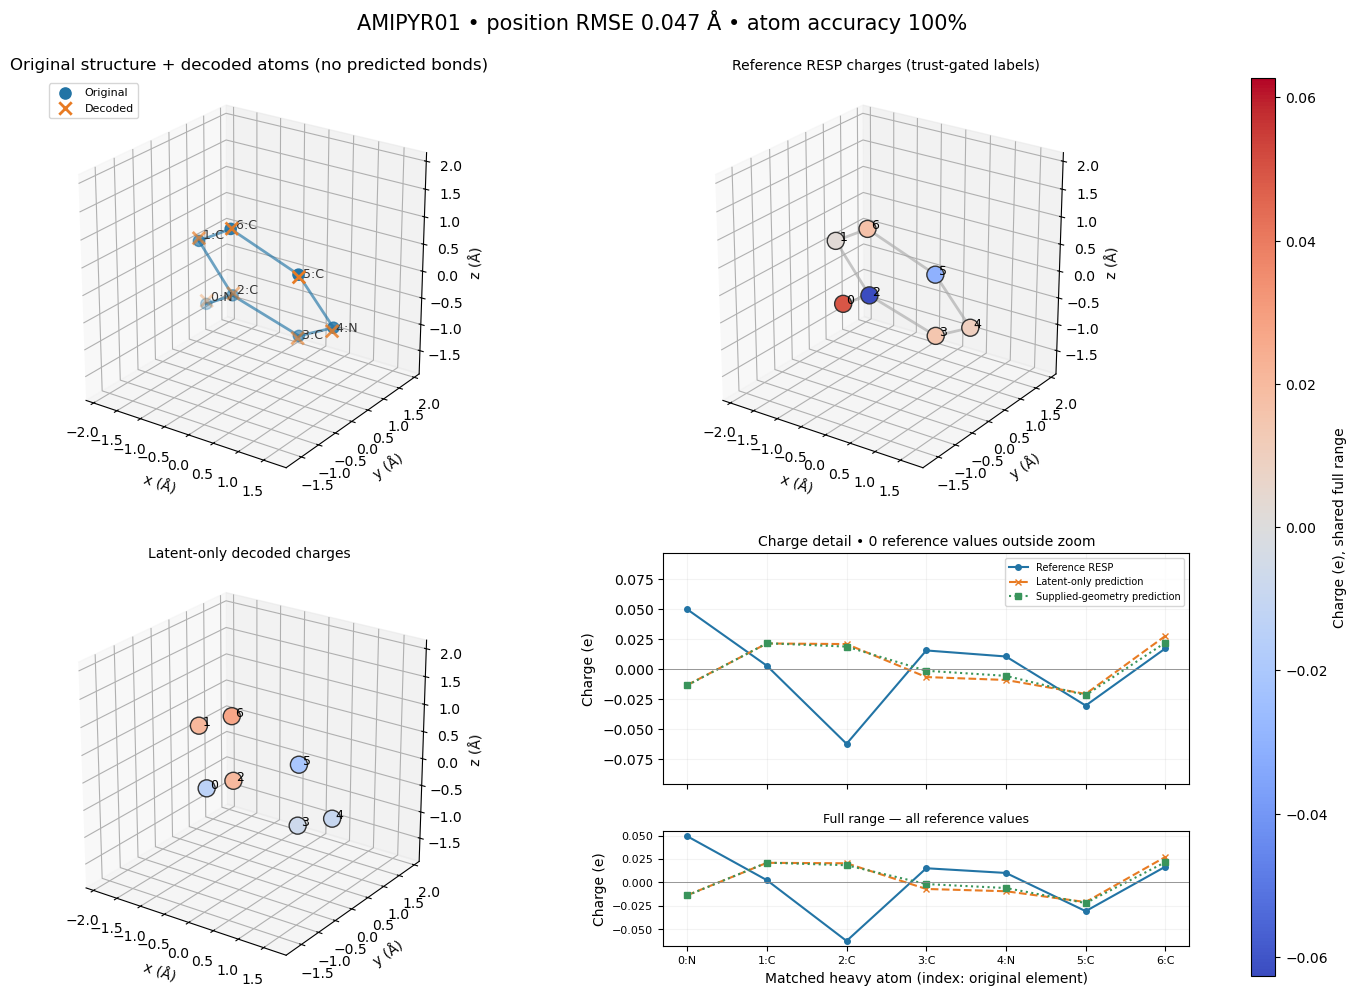

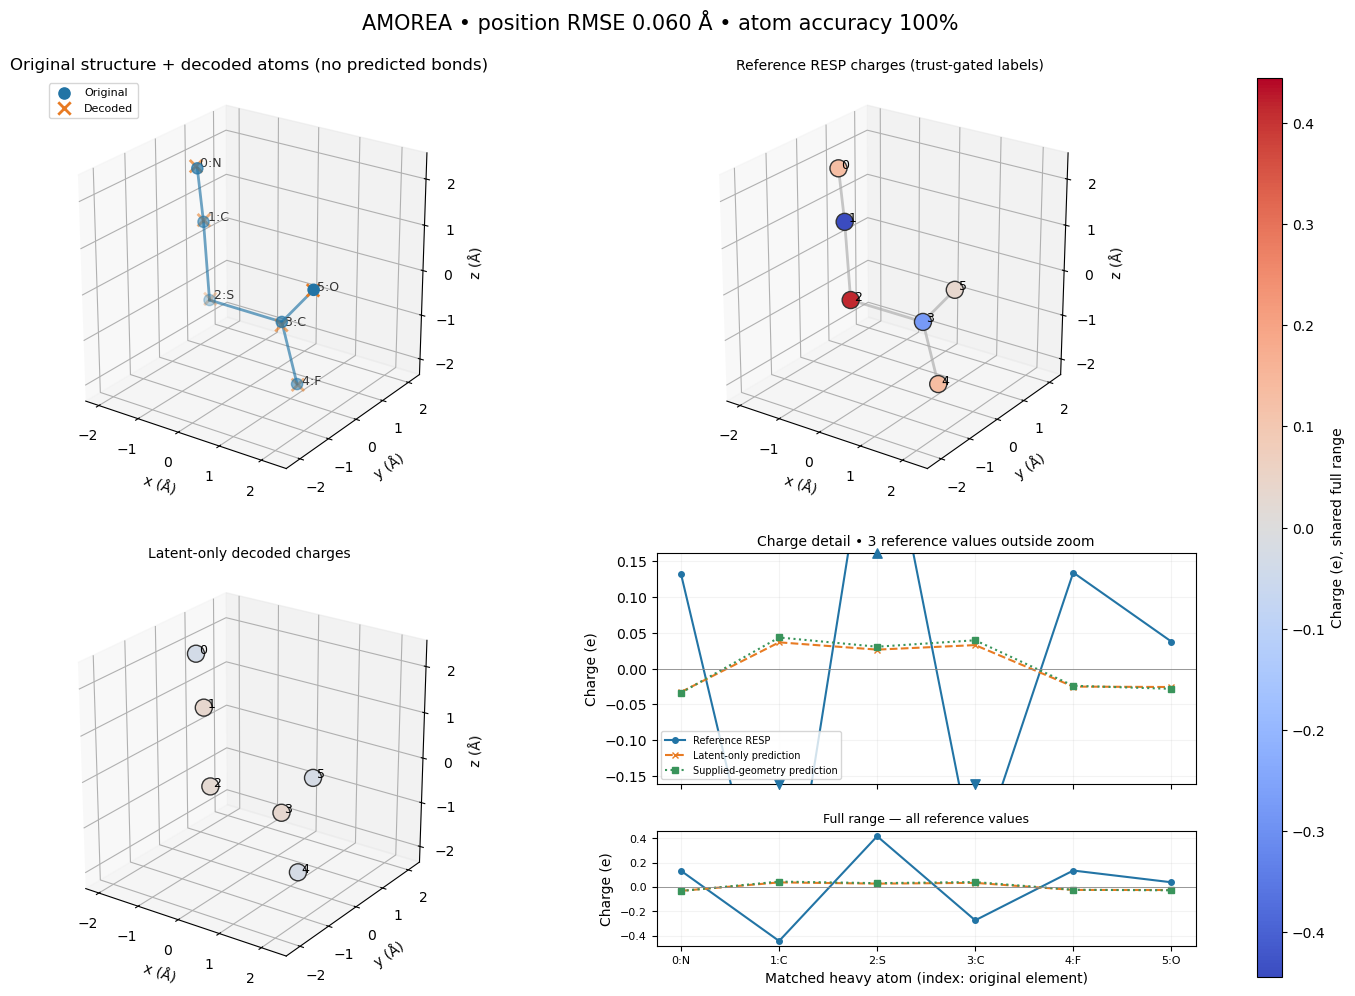

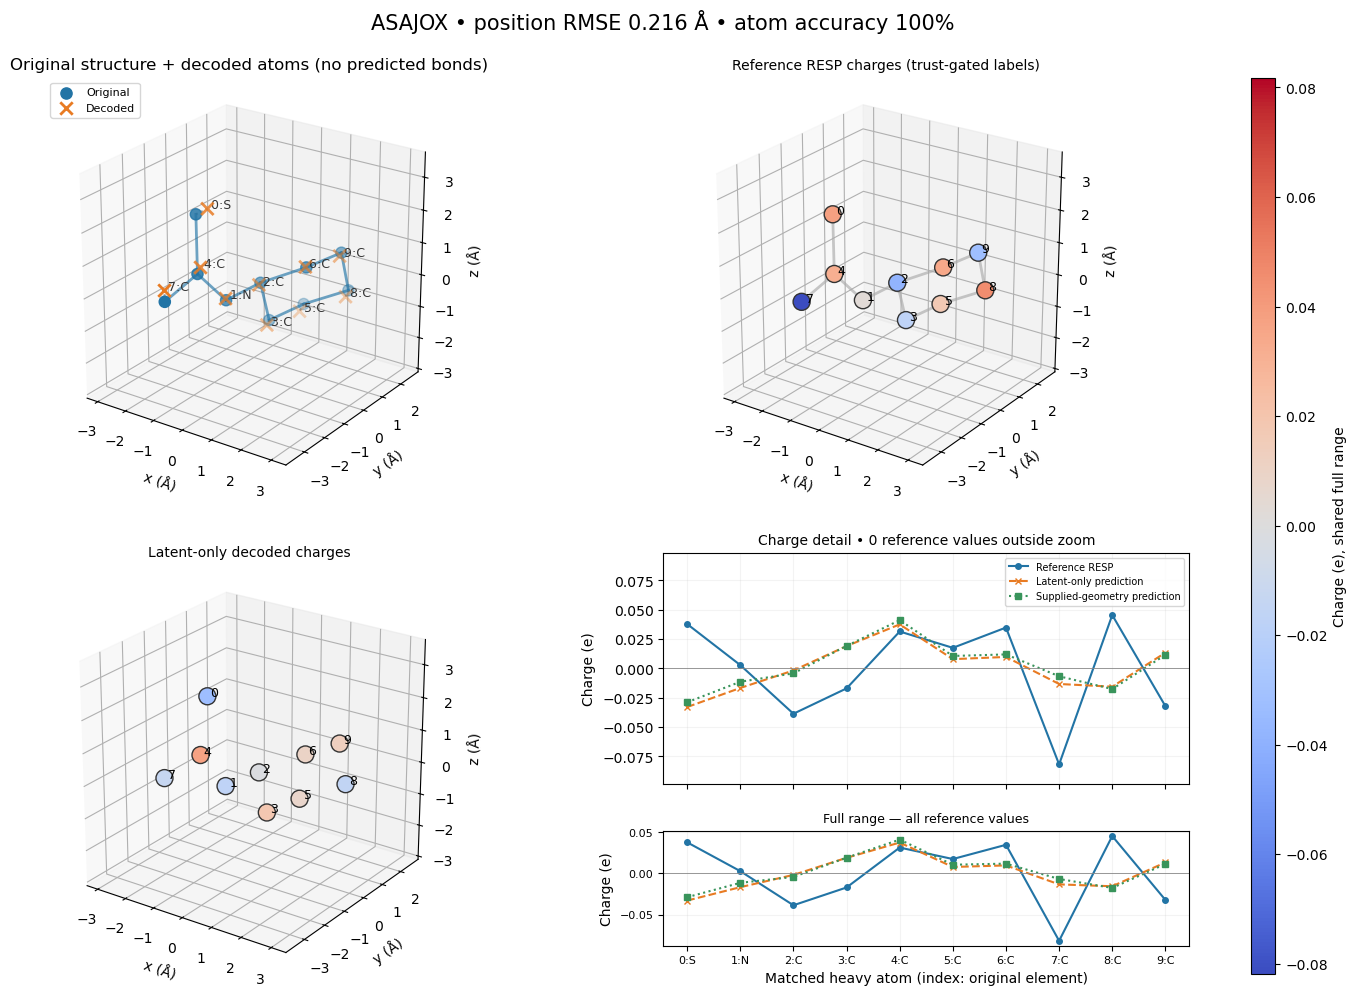

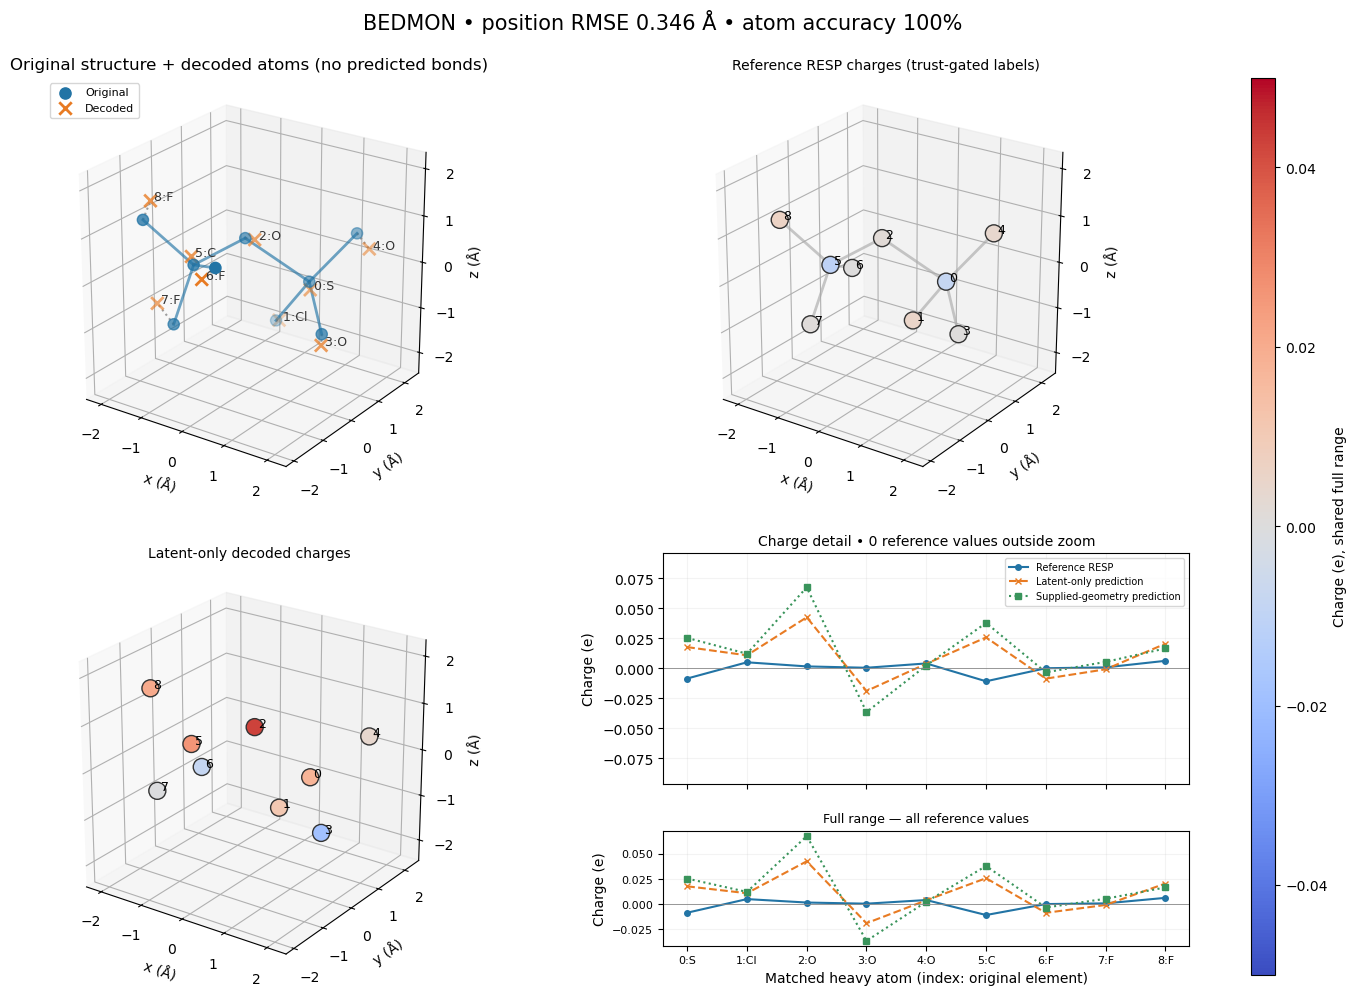

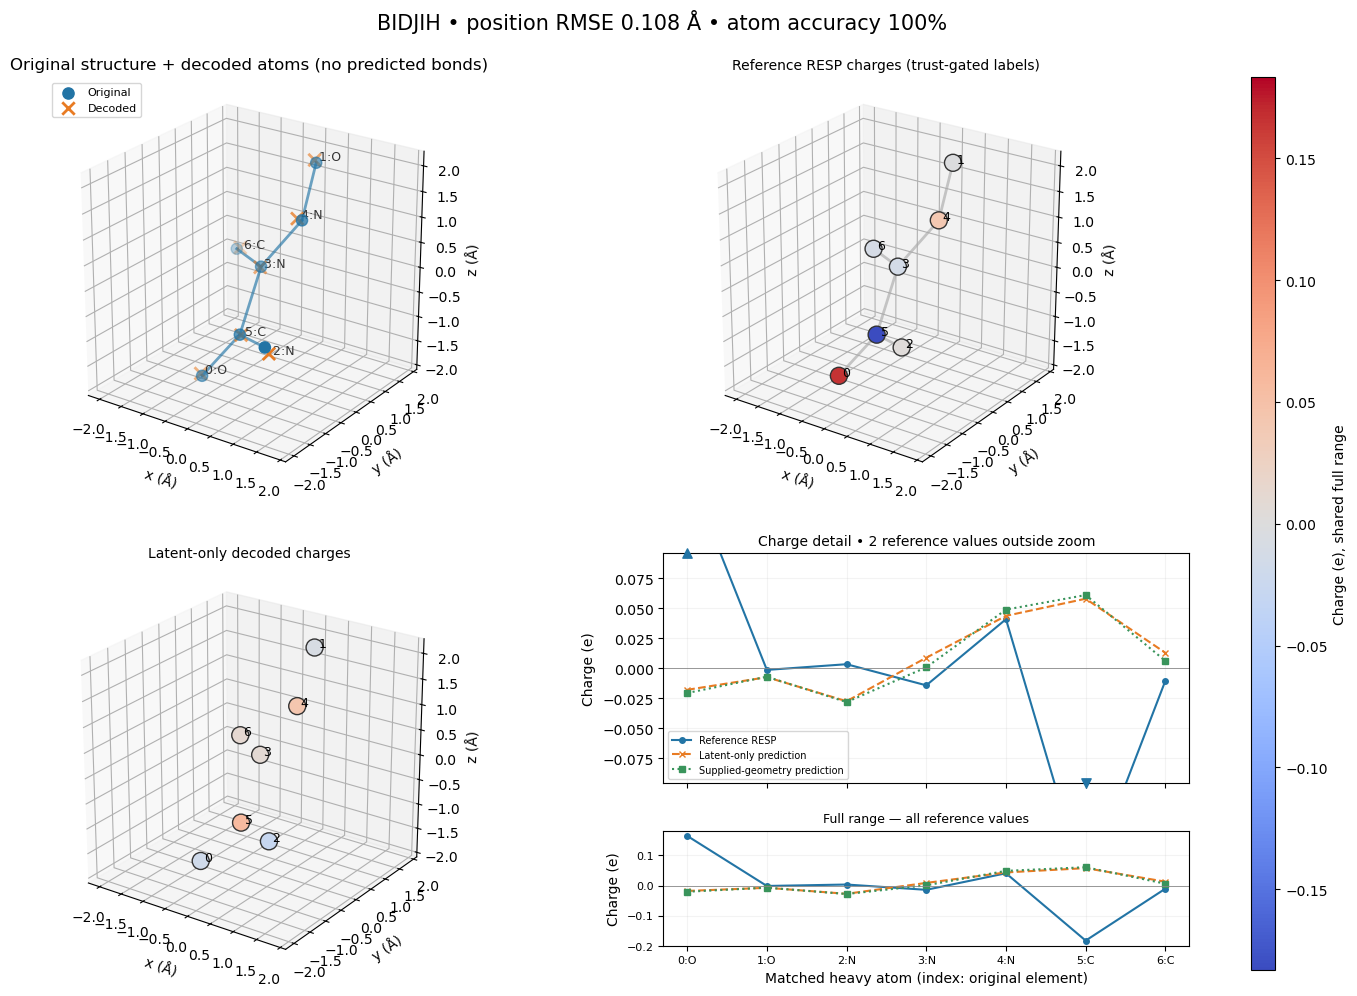

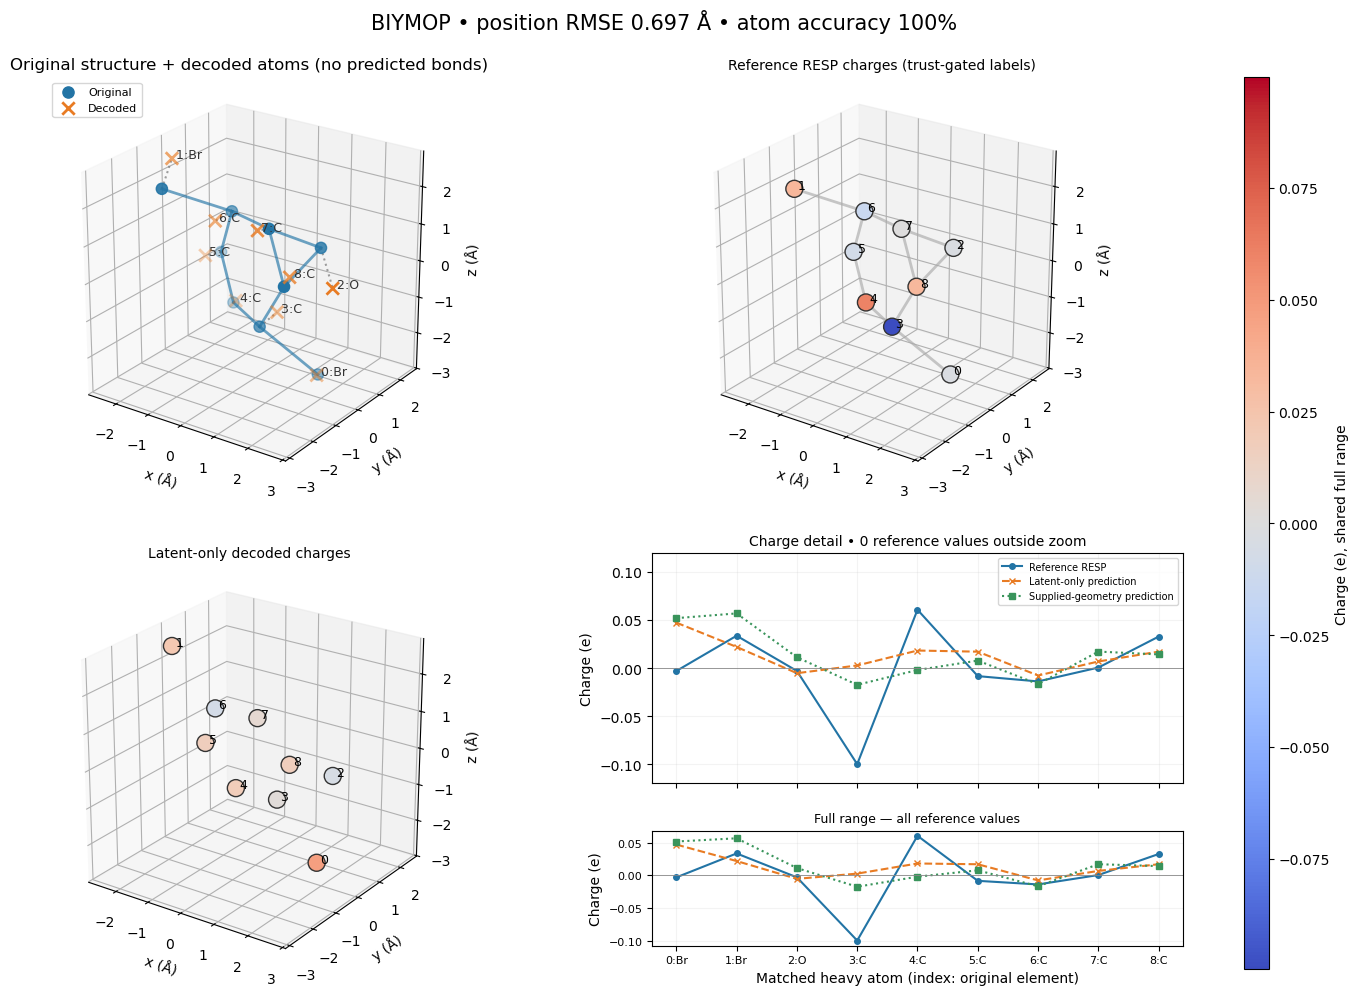

Saved figures and matched numerical predictions to /home/vlad/code/ccdc/runs/reconstruction-inspection-20260915T104537376847Z


In [4]:
from datetime import datetime, timezone
OUTPUT = ROOT / "runs" / ("reconstruction-inspection-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ"))
OUTPUT.mkdir(parents=True, exist_ok=False)
ELEVATION, AZIMUTH = 24, -55
CHARGE_YLIM = None  # Optional fixed zoom, e.g. (-0.3, 0.3)
BLUE, ORANGE = "#2274A5", "#E87B23"
periodic = Chem.GetPeriodicTable()

def setup_3d(ax, r):
    both = np.vstack([r["reference"], r["decoded"]])
    midpoint = (both.max(0) + both.min(0)) / 2
    radius = max(float(np.ptp(both, axis=0).max()) / 2, 0.5) + 0.35
    ax.set(xlim=(midpoint[0]-radius, midpoint[0]+radius),
           ylim=(midpoint[1]-radius, midpoint[1]+radius),
           zlim=(midpoint[2]-radius, midpoint[2]+radius),
           xlabel="x (Å)", ylabel="y (Å)", zlabel="z (Å)")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(ELEVATION, AZIMUTH)

def original_bonds(ax, r, color):
    for a, b in r["bonds"]:
        ax.plot(*r["reference"][[a, b]].T, color=color, linewidth=2, alpha=0.65)

for r in results:
    fig = plt.figure(figsize=(14, 10), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.15, h_pad=0.12, wspace=0.20)
    grid = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.045])
    overlay = fig.add_subplot(grid[0, 0], projection="3d")
    reference_ax = fig.add_subplot(grid[0, 1], projection="3d")
    decoded_ax = fig.add_subplot(grid[1, 0], projection="3d")
    charge_grid = grid[1, 1].subgridspec(2, 1, height_ratios=[2, 1])
    charge_ax = fig.add_subplot(charge_grid[0])
    full_ax = fig.add_subplot(charge_grid[1], sharex=charge_ax)
    fig.suptitle(f"{r['identifier']} • position RMSE {r['position_rmse_A']:.3f} Å • atom accuracy {r['atom_accuracy']:.0%}", fontsize=15)
    original_bonds(overlay, r, BLUE)
    overlay.scatter(*r["reference"].T, color=BLUE, s=65, label="Original")
    overlay.scatter(*r["decoded"].T, color=ORANGE, marker="x", s=80, linewidths=2, label="Decoded")
    for i, (a, b) in enumerate(zip(r["reference"], r["decoded"])):
        overlay.plot(*np.vstack([a,b]).T, color="#777777", linestyle=":", alpha=0.7)
        symbol = periodic.GetElementSymbol(int(r["decoded_z"][i]))
        wrong = r["reference_z"][i] != r["decoded_z"][i]
        overlay.text(*b, f" {i}:{symbol}", color="crimson" if wrong else "#333333", fontsize=9)
    overlay.set_title("Original structure + decoded atoms (no predicted bonds)")
    overlay.legend(loc="upper left", fontsize=8)
    limit = max(float(np.abs(np.r_[r['reference_q'], r['decoded_q']]).max()), 0.05)
    norm = Normalize(-limit, limit)
    original_bonds(reference_ax, r, "#aaaaaa")
    for ax, coords, q, title in [(reference_ax, r['reference'], r['reference_q'], 'Reference RESP charges (trust-gated labels)'),
                                (decoded_ax, r['decoded'], r['decoded_q'], 'Latent-only decoded charges')]:
        ax.scatter(*coords.T, c=q, cmap="coolwarm", norm=norm, s=150, edgecolors="#333333", depthshade=False)
        for i, point in enumerate(coords): ax.text(*point, f" {i}", fontsize=9)
        ax.set_title(title, fontsize=10)
    for ax in (overlay, reference_ax, decoded_ax): setup_3d(ax, r)
    fig.colorbar(ScalarMappable(norm=norm, cmap="coolwarm"), cax=fig.add_subplot(grid[:, 2]), label="Charge (e), shared full range")
    atom_ids = np.arange(len(r['reference_q']))
    prediction_extent = max(float(np.abs(np.r_[r['decoded_q'], r['geometry_q']]).max()), 0.08)
    nearby_reference = r['reference_q'][np.abs(r['reference_q']) <= 2 * prediction_extent]
    zoom_extent = max(prediction_extent, float(np.abs(nearby_reference).max()) if len(nearby_reference) else 0) * 1.2
    low, high = CHARGE_YLIM if CHARGE_YLIM is not None else (-zoom_extent, zoom_extent)
    if not np.isfinite([low, high]).all() or low >= high:
        raise ValueError("CHARGE_YLIM must contain two finite increasing values")
    for ax in (charge_ax, full_ax):
        ax.plot(atom_ids, r['reference_q'], 'o-', color=BLUE, label="Reference RESP", markersize=4)
        ax.plot(atom_ids, r['decoded_q'], 'x--', color=ORANGE, label="Latent-only prediction", markersize=5)
        ax.plot(atom_ids, r['geometry_q'], 's:', color="#39945B", label="Supplied-geometry prediction", markersize=4)
        ax.axhline(0, color="#888888", linewidth=0.6)
        ax.set_ylabel("Charge (e)")
        ax.grid(alpha=0.15)
    charge_ax.set_ylim(low, high)
    outside = (r['reference_q'] < low) | (r['reference_q'] > high)
    for mask, boundary, marker in [(r['reference_q'] > high, high, '^'), (r['reference_q'] < low, low, 'v')]:
        charge_ax.scatter(atom_ids[mask], np.full(mask.sum(), boundary), color=BLUE, marker=marker, s=45, clip_on=False, zorder=5)
    charge_ax.set_title(f"Charge detail • {outside.sum()} reference values outside zoom", fontsize=10)
    charge_ax.legend(fontsize=7, loc="best")
    charge_ax.tick_params(labelbottom=False)
    full_ax.set(xticks=atom_ids, xticklabels=[f"{i}:{periodic.GetElementSymbol(int(z))}" for i,z in enumerate(r['reference_z'])],
                xlabel="Matched heavy atom (index: original element)", title="Full range — all reference values")
    full_ax.title.set_fontsize(9)
    full_ax.tick_params(labelsize=8)
    fig.savefig(OUTPUT / f"{r['identifier']}.png", dpi=130)
    plt.show()
    plt.close(fig)

serializable = [{k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in r.items()} for r in results]
(OUTPUT / "predictions.json").write_text(json.dumps({"checkpoint":str(CHECKPOINT), "checkpoint_sha256":digest(CHECKPOINT),
    "seed":SEED, "sample_steps":SAMPLE_STEPS, "device":str(device), "molecules":serializable}, indent=2) + "\n")
print("Saved figures and matched numerical predictions to", OUTPUT)
